# M1.Ex3: Iris Classification

- Run: [**Open In Colab**](https://colab.research.google.com/github/HassanAlgoz/B5/blob/main/content/W3/M1/exercises/ex3_class.ipynb)
- Dataset:`sklearn.datasets.load_iris()`

In [3]:
import pandas as pd
import sklearn
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.inspection import DecisionBoundaryDisplay
from sklearn.metrics import accuracy_score, classification_report
import numpy as np

![Iris Flowers](../assets/iris_flowers.png)

### Step 1.a Load the data

In [4]:
iris = sklearn.datasets.load_iris(as_frame=True)

### Step 2.a Assign variables `X` to the features and `y` to the target

In [8]:
X = iris.data
y = iris.target

print(X.head())
print(y.head())

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                5.1               3.5                1.4               0.2
1                4.9               3.0                1.4               0.2
2                4.7               3.2                1.3               0.2
3                4.6               3.1                1.5               0.2
4                5.0               3.6                1.4               0.2
0    0
1    0
2    0
3    0
4    0
Name: target, dtype: int64


### Step 2.b print the type of each

In [9]:
print('Type of X:', type(X))
print('Type of y:', type(y))
print('dtype of X:', X.dtypes.to_dict())
print('dtype of y:', y.dtype)

Type of X: <class 'pandas.DataFrame'>
Type of y: <class 'pandas.Series'>
dtype of X: {'sepal length (cm)': dtype('float64'), 'sepal width (cm)': dtype('float64'), 'petal length (cm)': dtype('float64'), 'petal width (cm)': dtype('float64')}
dtype of y: int64


### Step 2.c identify whether the target is categorical or numerical & whether the task is regression or classification

In [10]:
print('Unique target values:', y.unique())
print('Target names:', iris.target_names)
print()
print('The target is CATEGORICAL — it represents 3 discrete flower species (setosa, versicolor, virginica).')
print('The task is CLASSIFICATION (multi-class, 3 classes).')

Unique target values: [0 1 2]
Target names: ['setosa' 'versicolor' 'virginica']

The target is CATEGORICAL — it represents 3 discrete flower species (setosa, versicolor, virginica).
The task is CLASSIFICATION (multi-class, 3 classes).


### Step 3. Identify the number of samples and columns of both the data matrix and the target

In [11]:
print(f'X shape: {X.shape}  →  {X.shape[0]} samples, {X.shape[1]} features')
print(f'y shape: {y.shape}  →  {y.shape[0]} samples, 1 target column')

X shape: (150, 4)  →  150 samples, 4 features
y shape: (150,)  →  150 samples, 1 target column


### Step 4. Summarize the distribution of the data (min, max, median, mean, and standard deviation)

In [12]:
stats = X.agg(['min', 'max', 'median', 'mean', 'std'])
print(stats.round(2))

        sepal length (cm)  sepal width (cm)  petal length (cm)  \
min                  4.30              2.00               1.00   
max                  7.90              4.40               6.90   
median               5.80              3.00               4.35   
mean                 5.84              3.06               3.76   
std                  0.83              0.44               1.77   

        petal width (cm)  
min                 0.10  
max                 2.50  
median              1.30  
mean                1.20  
std                 0.76  


### Step 5. Plot the features to identify separability. Can you see clearly distinguishable groups of points?

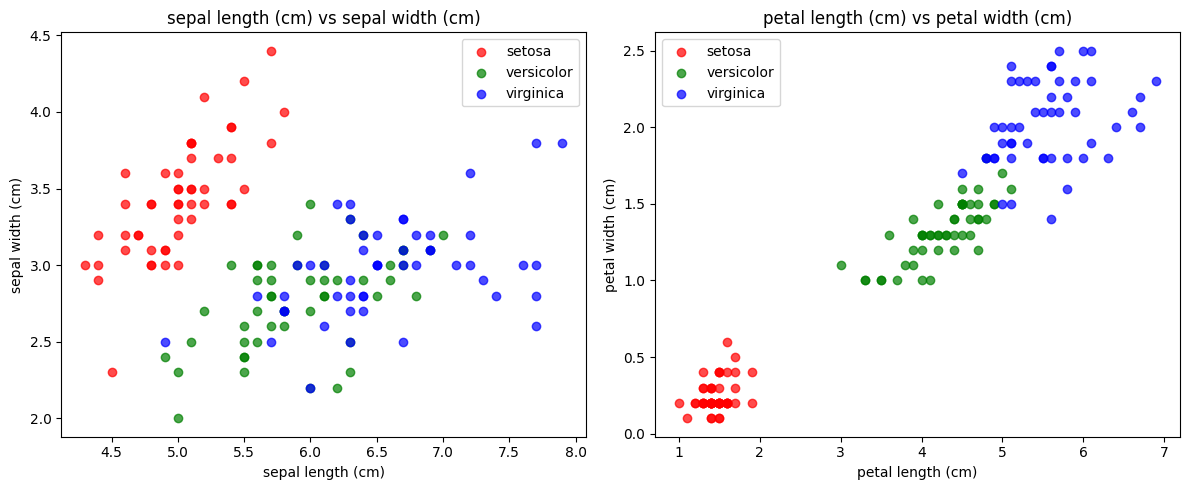

Sepal features: classes overlap, poor separability.
Petal features: clearly separated clusters, much better separability.


In [13]:
colors = ['red', 'green', 'blue']
feature_pairs = [
    ('sepal length (cm)', 'sepal width (cm)'),
    ('petal length (cm)', 'petal width (cm)')
]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, (fx, fy) in zip(axes, feature_pairs):
    for cls in y.unique():
        mask = y == cls
        ax.scatter(X.loc[mask, fx], X.loc[mask, fy],
                   label=iris.target_names[cls], color=colors[cls], alpha=0.7)
    ax.set_xlabel(fx)
    ax.set_ylabel(fy)
    ax.set_title(f'{fx} vs {fy}')
    ax.legend()

plt.tight_layout()
plt.show()

print('Sepal features: classes overlap, poor separability.')
print('Petal features: clearly separated clusters, much better separability.')

### Step 6. Keep the following in "Steps 7" onwards

1. First model will trian on the features: `sepal length (cm)` & `sepal width (cm)`
2. Second model will train on the features: `petal length (cm)` & `petal width (cm)`

Finally, evaluate and compare which of the two feature-sets scored better.

Let's do both subsets now..

### Step 6.a subset the features `sepal length (cm)` & `sepal width (cm)`


In [14]:
X_sepal = X[['sepal length (cm)', 'sepal width (cm)']]
print(X_sepal.head())

   sepal length (cm)  sepal width (cm)
0                5.1               3.5
1                4.9               3.0
2                4.7               3.2
3                4.6               3.1
4                5.0               3.6


### Step 6.b subset the features `petal length (cm)` & `petal width (cm)`


In [15]:
X_petal = X[['petal length (cm)', 'petal width (cm)']]
print(X_petal.head())

   petal length (cm)  petal width (cm)
0                1.4               0.2
1                1.4               0.2
2                1.3               0.2
3                1.5               0.2
4                1.4               0.2


### Step 7. Initialize 2 `LogisticRegression` models

In [16]:
model_sepal = LogisticRegression(max_iter=200, random_state=42)
model_petal = LogisticRegression(max_iter=200, random_state=42)

### Step 8. Split the dataset into train and test sets (remember to stratify by the target to account for class imbalance)

In [17]:
X_sepal_train, X_sepal_test, y_sepal_train, y_sepal_test = train_test_split(
    X_sepal, y, test_size=0.2, random_state=42, stratify=y
)

X_petal_train, X_petal_test, y_petal_train, y_petal_test = train_test_split(
    X_petal, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Sepal — train: {X_sepal_train.shape[0]}, test: {X_sepal_test.shape[0]}')
print(f'Petal — train: {X_petal_train.shape[0]}, test: {X_petal_test.shape[0]}')

Sepal — train: 120, test: 30
Petal — train: 120, test: 30


### Step 9.a Train both models

In [18]:
model_sepal.fit(X_sepal_train, y_sepal_train)
model_petal.fit(X_petal_train, y_petal_train)

print('Both models trained.')

Both models trained.


### Step 10. Evaluate and compare both models

In [19]:
y_pred_sepal = model_sepal.predict(X_sepal_test)
y_pred_petal = model_petal.predict(X_petal_test)

acc_sepal = accuracy_score(y_sepal_test, y_pred_sepal)
acc_petal = accuracy_score(y_petal_test, y_pred_petal)

print(f'Sepal model accuracy:  {acc_sepal:.4f}')
print(f'Petal model accuracy:  {acc_petal:.4f}')
print()
print('--- Sepal model classification report ---')
print(classification_report(y_sepal_test, y_pred_sepal, target_names=iris.target_names))
print('--- Petal model classification report ---')
print(classification_report(y_petal_test, y_pred_petal, target_names=iris.target_names))

Sepal model accuracy:  0.7333
Petal model accuracy:  0.9667

--- Sepal model classification report ---
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.62      0.50      0.56        10
   virginica       0.58      0.70      0.64        10

    accuracy                           0.73        30
   macro avg       0.74      0.73      0.73        30
weighted avg       0.74      0.73      0.73        30

--- Petal model classification report ---
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



### Step 11. Which of the two subset of features better distinguishes iris flowers? Can you easily tell?

In [20]:
winner = 'Petal' if acc_petal > acc_sepal else 'Sepal'
print(f'Sepal accuracy: {acc_sepal:.4f}')
print(f'Petal accuracy: {acc_petal:.4f}')
print()
print(f'{winner} features better distinguish iris flowers.')
print()
print('Yes, it is easy to tell from both the scatter plot (Step 5) and the accuracy scores.')
print('Petal length and petal width form tight, well-separated clusters per class,')
print('whereas sepal features show significant overlap — especially between versicolor and virginica.')

Sepal accuracy: 0.7333
Petal accuracy: 0.9667

Petal features better distinguish iris flowers.

Yes, it is easy to tell from both the scatter plot (Step 5) and the accuracy scores.
Petal length and petal width form tight, well-separated clusters per class,
whereas sepal features show significant overlap — especially between versicolor and virginica.


### Step 12. Use `DecisionBoundaryDisplay` to plot the learned decision boundary

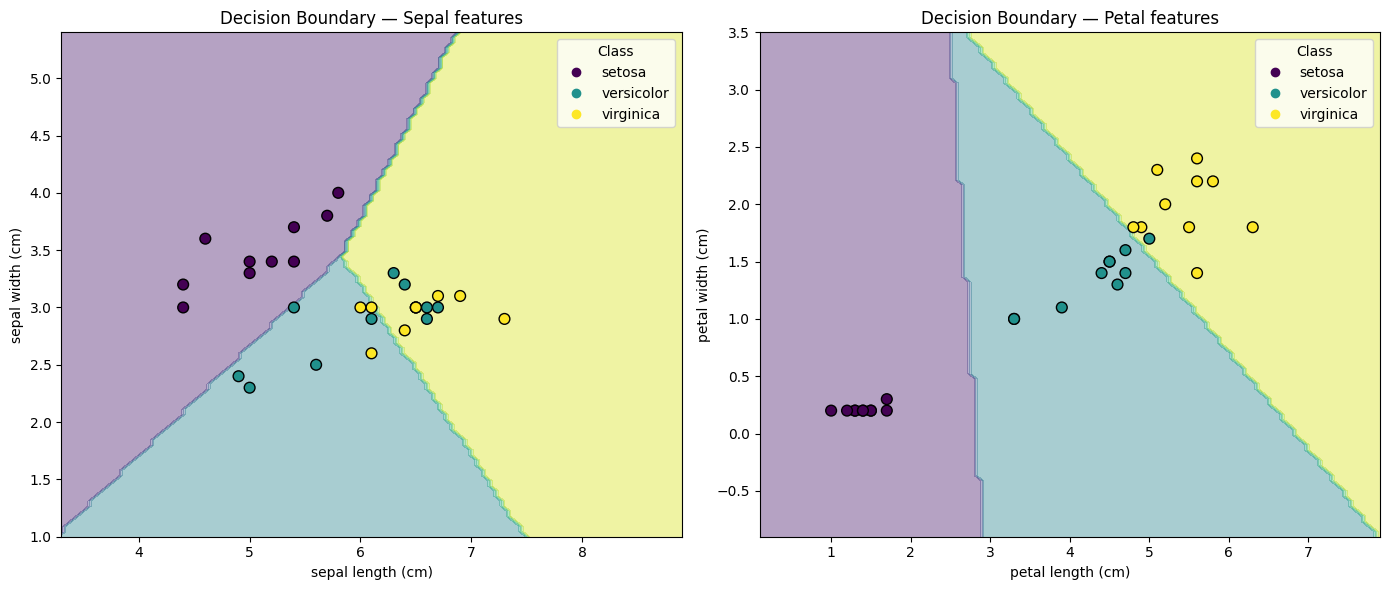

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

configs = [
    (model_sepal, X_sepal_train, X_sepal_test, y_sepal_test, 'Sepal features', ['sepal length (cm)', 'sepal width (cm)']),
    (model_petal, X_petal_train, X_petal_test, y_petal_test, 'Petal features', ['petal length (cm)', 'petal width (cm)'])
]

for ax, (model, X_train, X_test, y_test, title, feat_names) in zip(axes, configs):
    disp = DecisionBoundaryDisplay.from_estimator(
        model, X_train,
        response_method='predict',
        alpha=0.4,
        ax=ax
    )
    scatter = ax.scatter(
        X_test.iloc[:, 0], X_test.iloc[:, 1],
        c=y_test, edgecolors='k', s=60
    )
    ax.set_xlabel(feat_names[0])
    ax.set_ylabel(feat_names[1])
    ax.set_title(f'Decision Boundary — {title}')
    legend = ax.legend(
        handles=scatter.legend_elements()[0],
        labels=list(iris.target_names),
        title='Class'
    )

plt.tight_layout()
plt.show()